# Dataset Review

This notebook checks whether the generated measurement data looks believable for training a diagnosis model. Here, a **fault** means the main problem class assigned to one episode, such as clock synchronization loss, polarization drift, Raman noise, extra loss, or temperature-driven peak shift.

The goal is not to plot every column. The goal is to answer five practical questions:

1. Do we have the expected number of examples for each fault?
2. Does each fault change the measurements in the expected direction?
3. Does one concrete example of each fault look reasonable over time?
4. Do the different fault trajectory styles really look different?
5. Does the temperature fault use the physical 24-hour time axis correctly?


## Setup

Set `DATASET_DIR` to the generated dataset folder you want to review. The notebook writes review figures into `<dataset>/review_artifacts/`.


In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

CWD = Path.cwd().resolve()
if (CWD / 'review_dataset.py').exists():
    MODULE_DIR = CWD
    REPO_ROOT = MODULE_DIR.parents[2]
else:
    REPO_ROOT = CWD
    MODULE_DIR = REPO_ROOT / 'example' / 'entanglement_distribution_experiment' / 'ai_diagnosis_dataset'

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from review_dataset import (
    ensure_numeric,
    load_dataset,
    plot_dataset_composition,
    plot_fault_change_summary,
    plot_representative_fault_examples,
    plot_fault_trajectory_styles,
    plot_temperature_physical_time,
    write_summary,
)


In [2]:
DATASET_DIR = MODULE_DIR / 'generated' / 'train_v5_60s_100khz_24h_temperature'
OUTPUT_DIR = DATASET_DIR / 'review_artifacts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR


WindowsPath('C:/Users/ana35/OneDrive - NIST/Desktop/cooding/SeQUeNCe/example/entanglement_distribution_experiment/ai_diagnosis_dataset/generated/train_v5_60s_100khz_24h_temperature')

## Load The Dataset

This cell loads the measurement windows, the episode-level fault labels, validation summaries, and generation metadata. It also converts numeric columns to numeric types so the plots behave consistently.


In [3]:
observable, sequence, validation, metadata = load_dataset(DATASET_DIR)
observable = ensure_numeric(observable)

print(f"Episodes: {len(sequence)}")
print(f"Measurement windows: {len(observable)}")
print(f"Window duration: {metadata.get('window_duration_s')} s")
print(f"Temperature physical span: {metadata.get('temperature_episode_span_s')} s")

sequence.head()


Episodes: 3000
Measurement windows: 180000
Window duration: 1.0 s
Temperature physical span: 86400.0 s


,sample_id,label,trajectory_variant,windows,fault_onset_window,validation_attempt,validation_passed
0,loss_000,loss,progressive,60,20,1,NaN
1,loss_001,loss,recovering,60,20,1,NaN
2,loss_002,loss,oscillatory,60,20,1,NaN
3,loss_003,loss,intermittent,60,20,1,NaN
4,loss_004,loss,progressive,60,20,1,NaN


## Plot 1: Dataset Composition

This plot checks balance. The left side shows how many episodes exist for each fault type. The right side shows whether each non-normal fault has examples of the different trajectory styles: gets worse, partly recovers, oscillates, or happens in bursts.


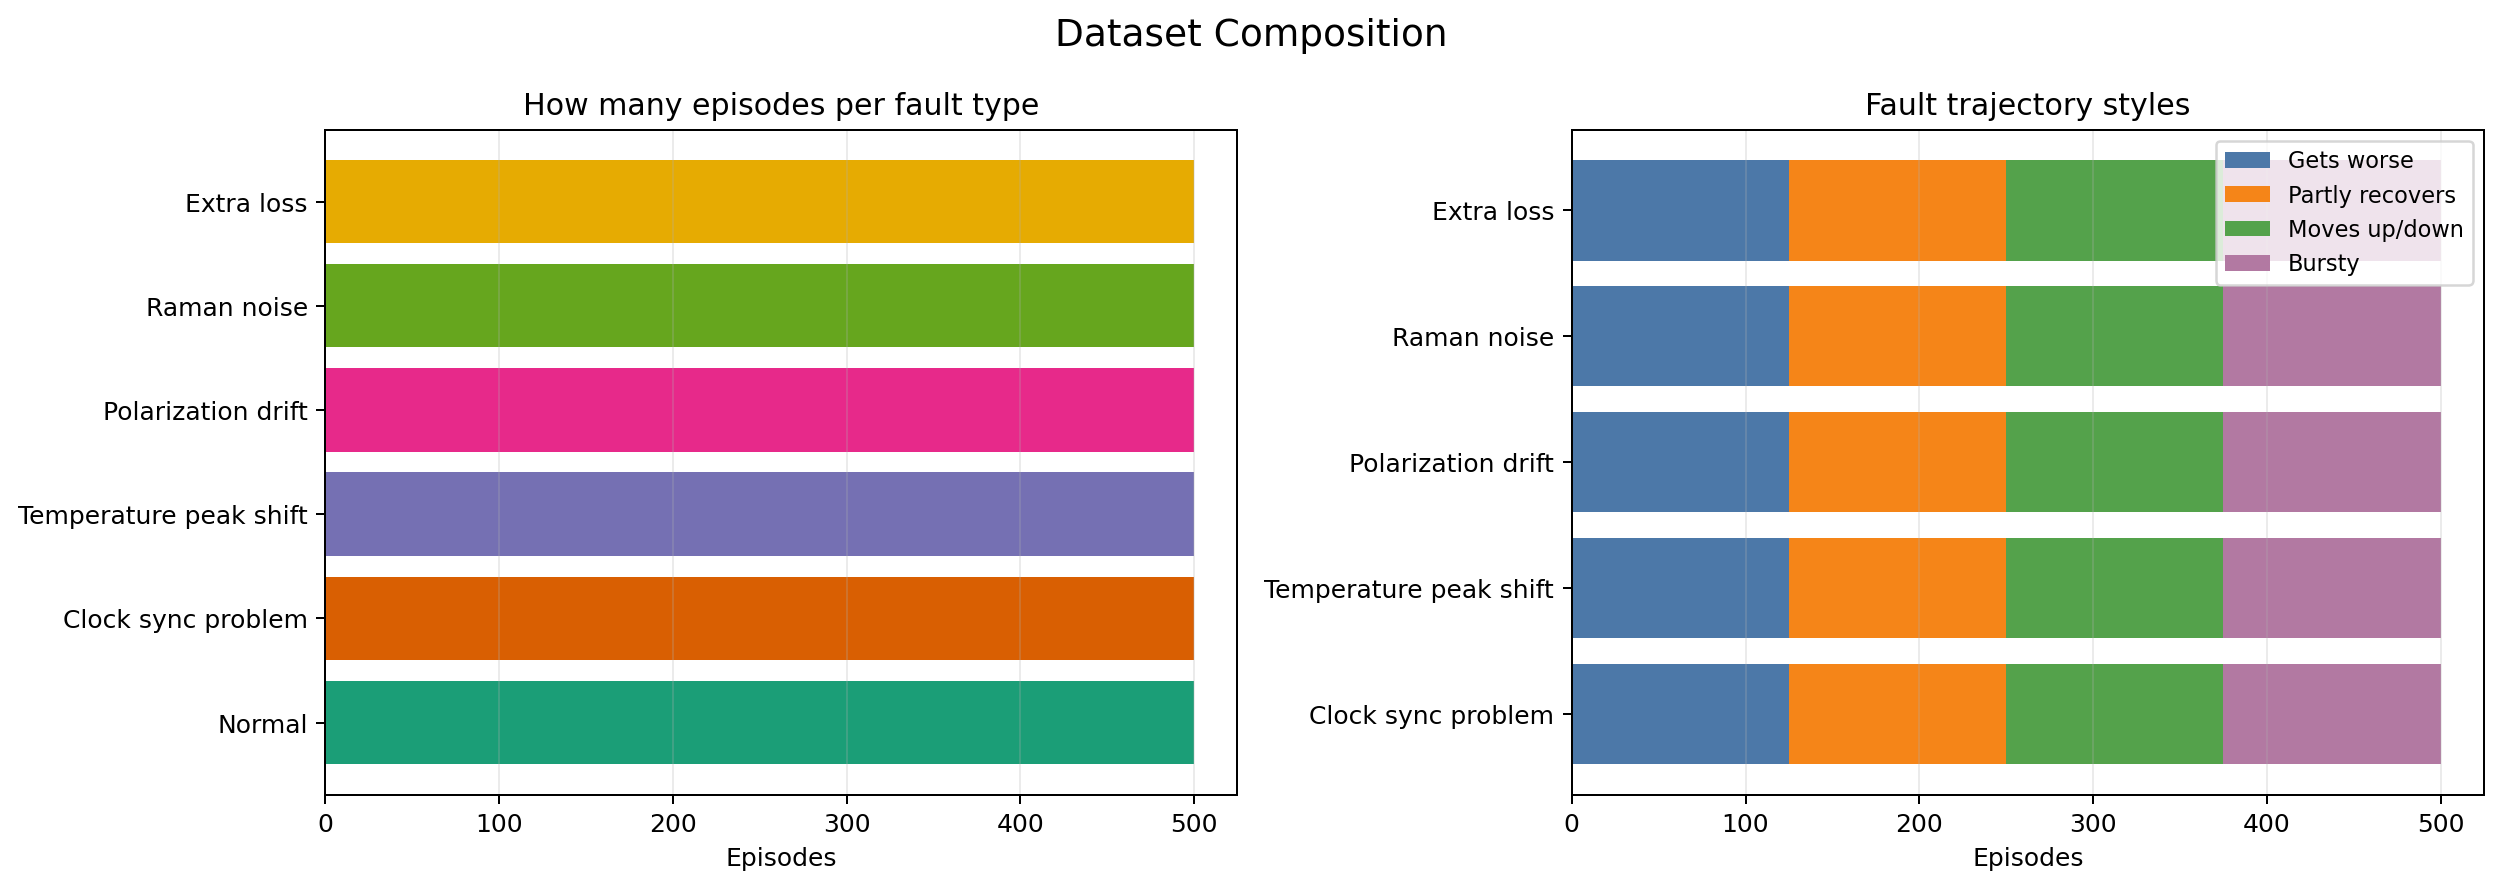

In [4]:
plot_dataset_composition(sequence, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / '01_dataset_composition.png')))


## Plot 2: Typical Change After The Fault Starts

This plot summarizes the median change from before the fault starts to after it starts. It is meant to answer: does each fault push the right measurement signals?

Expected high-level behavior:

- Clock sync problem: lower peak quality and lower CAR.
- Temperature peak shift: larger peak-position change and visible temperature change.
- Polarization drift: lower ZZ correlation.
- Raman noise: higher singles/accidentals and lower CAR.
- Extra loss: lower coincidence and singles rates.


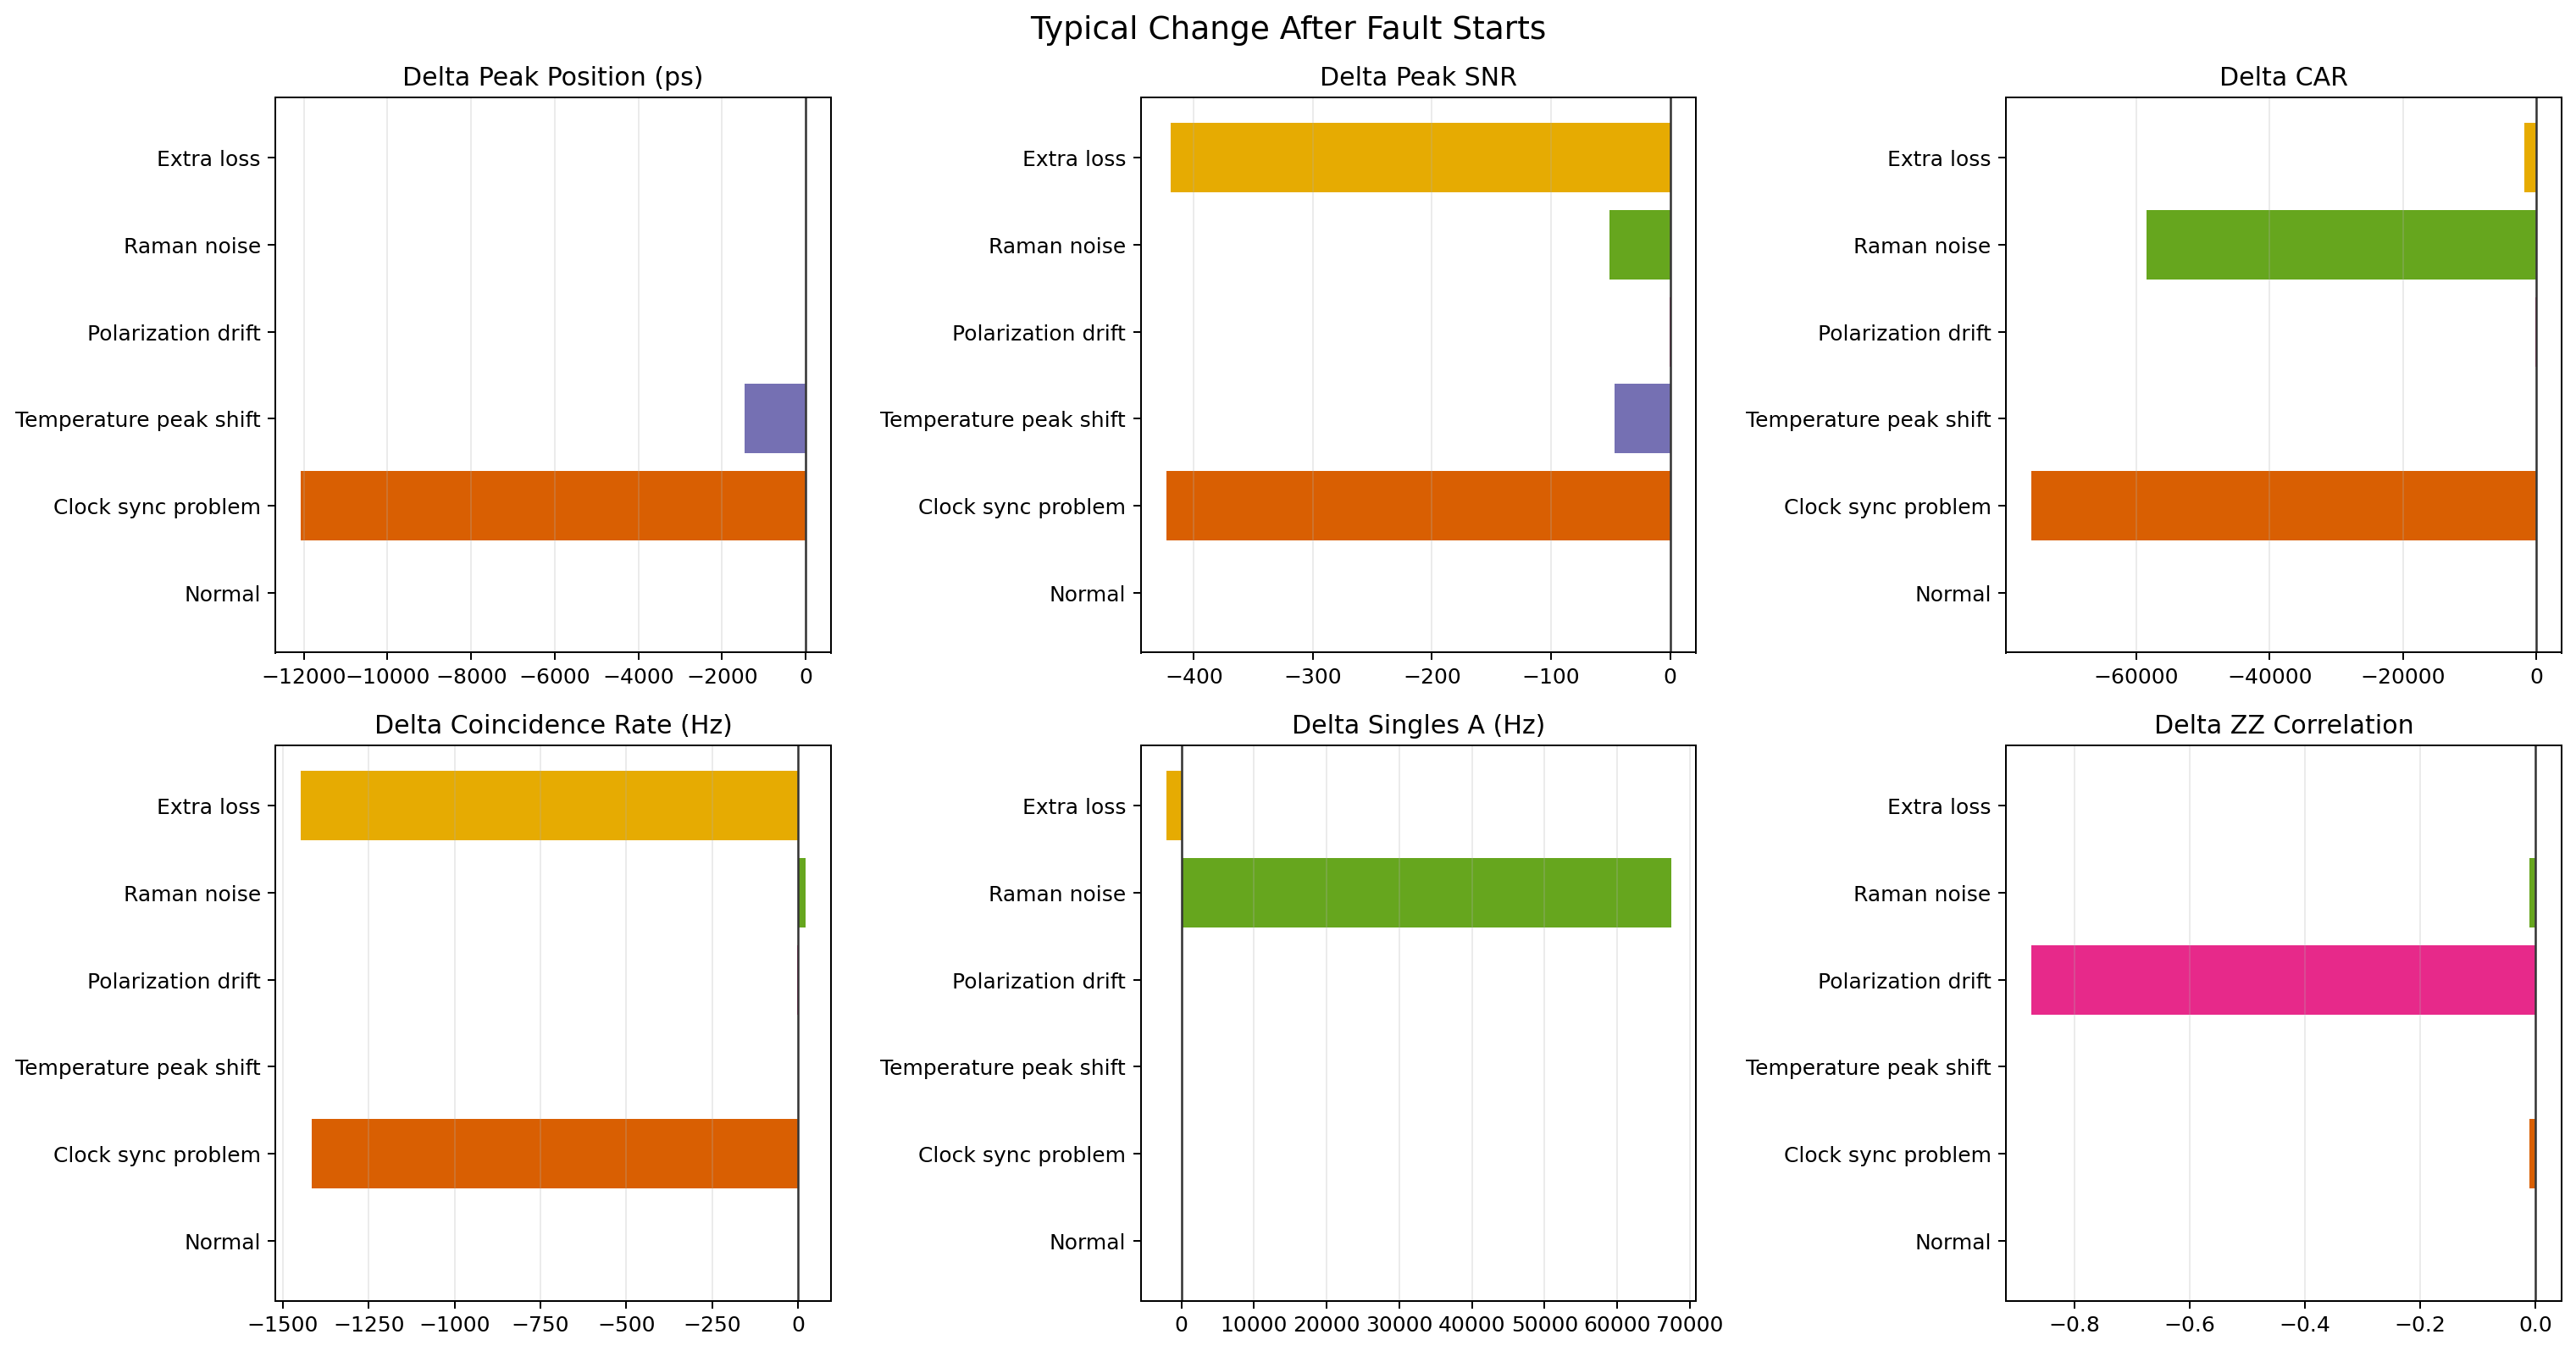

In [5]:
plot_fault_change_summary(validation, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / '02_fault_change_summary.png')))


## Plot 3: One Example Episode Per Fault Type

This plot shows one selected episode for each fault type. The dashed vertical line is when the fault starts. These are not averages; each row is one concrete simulated episode.

The columns are intentionally limited to the most useful signals for diagnosis: peak position, CAR, coincidence rate, singles rate, and ZZ correlation.


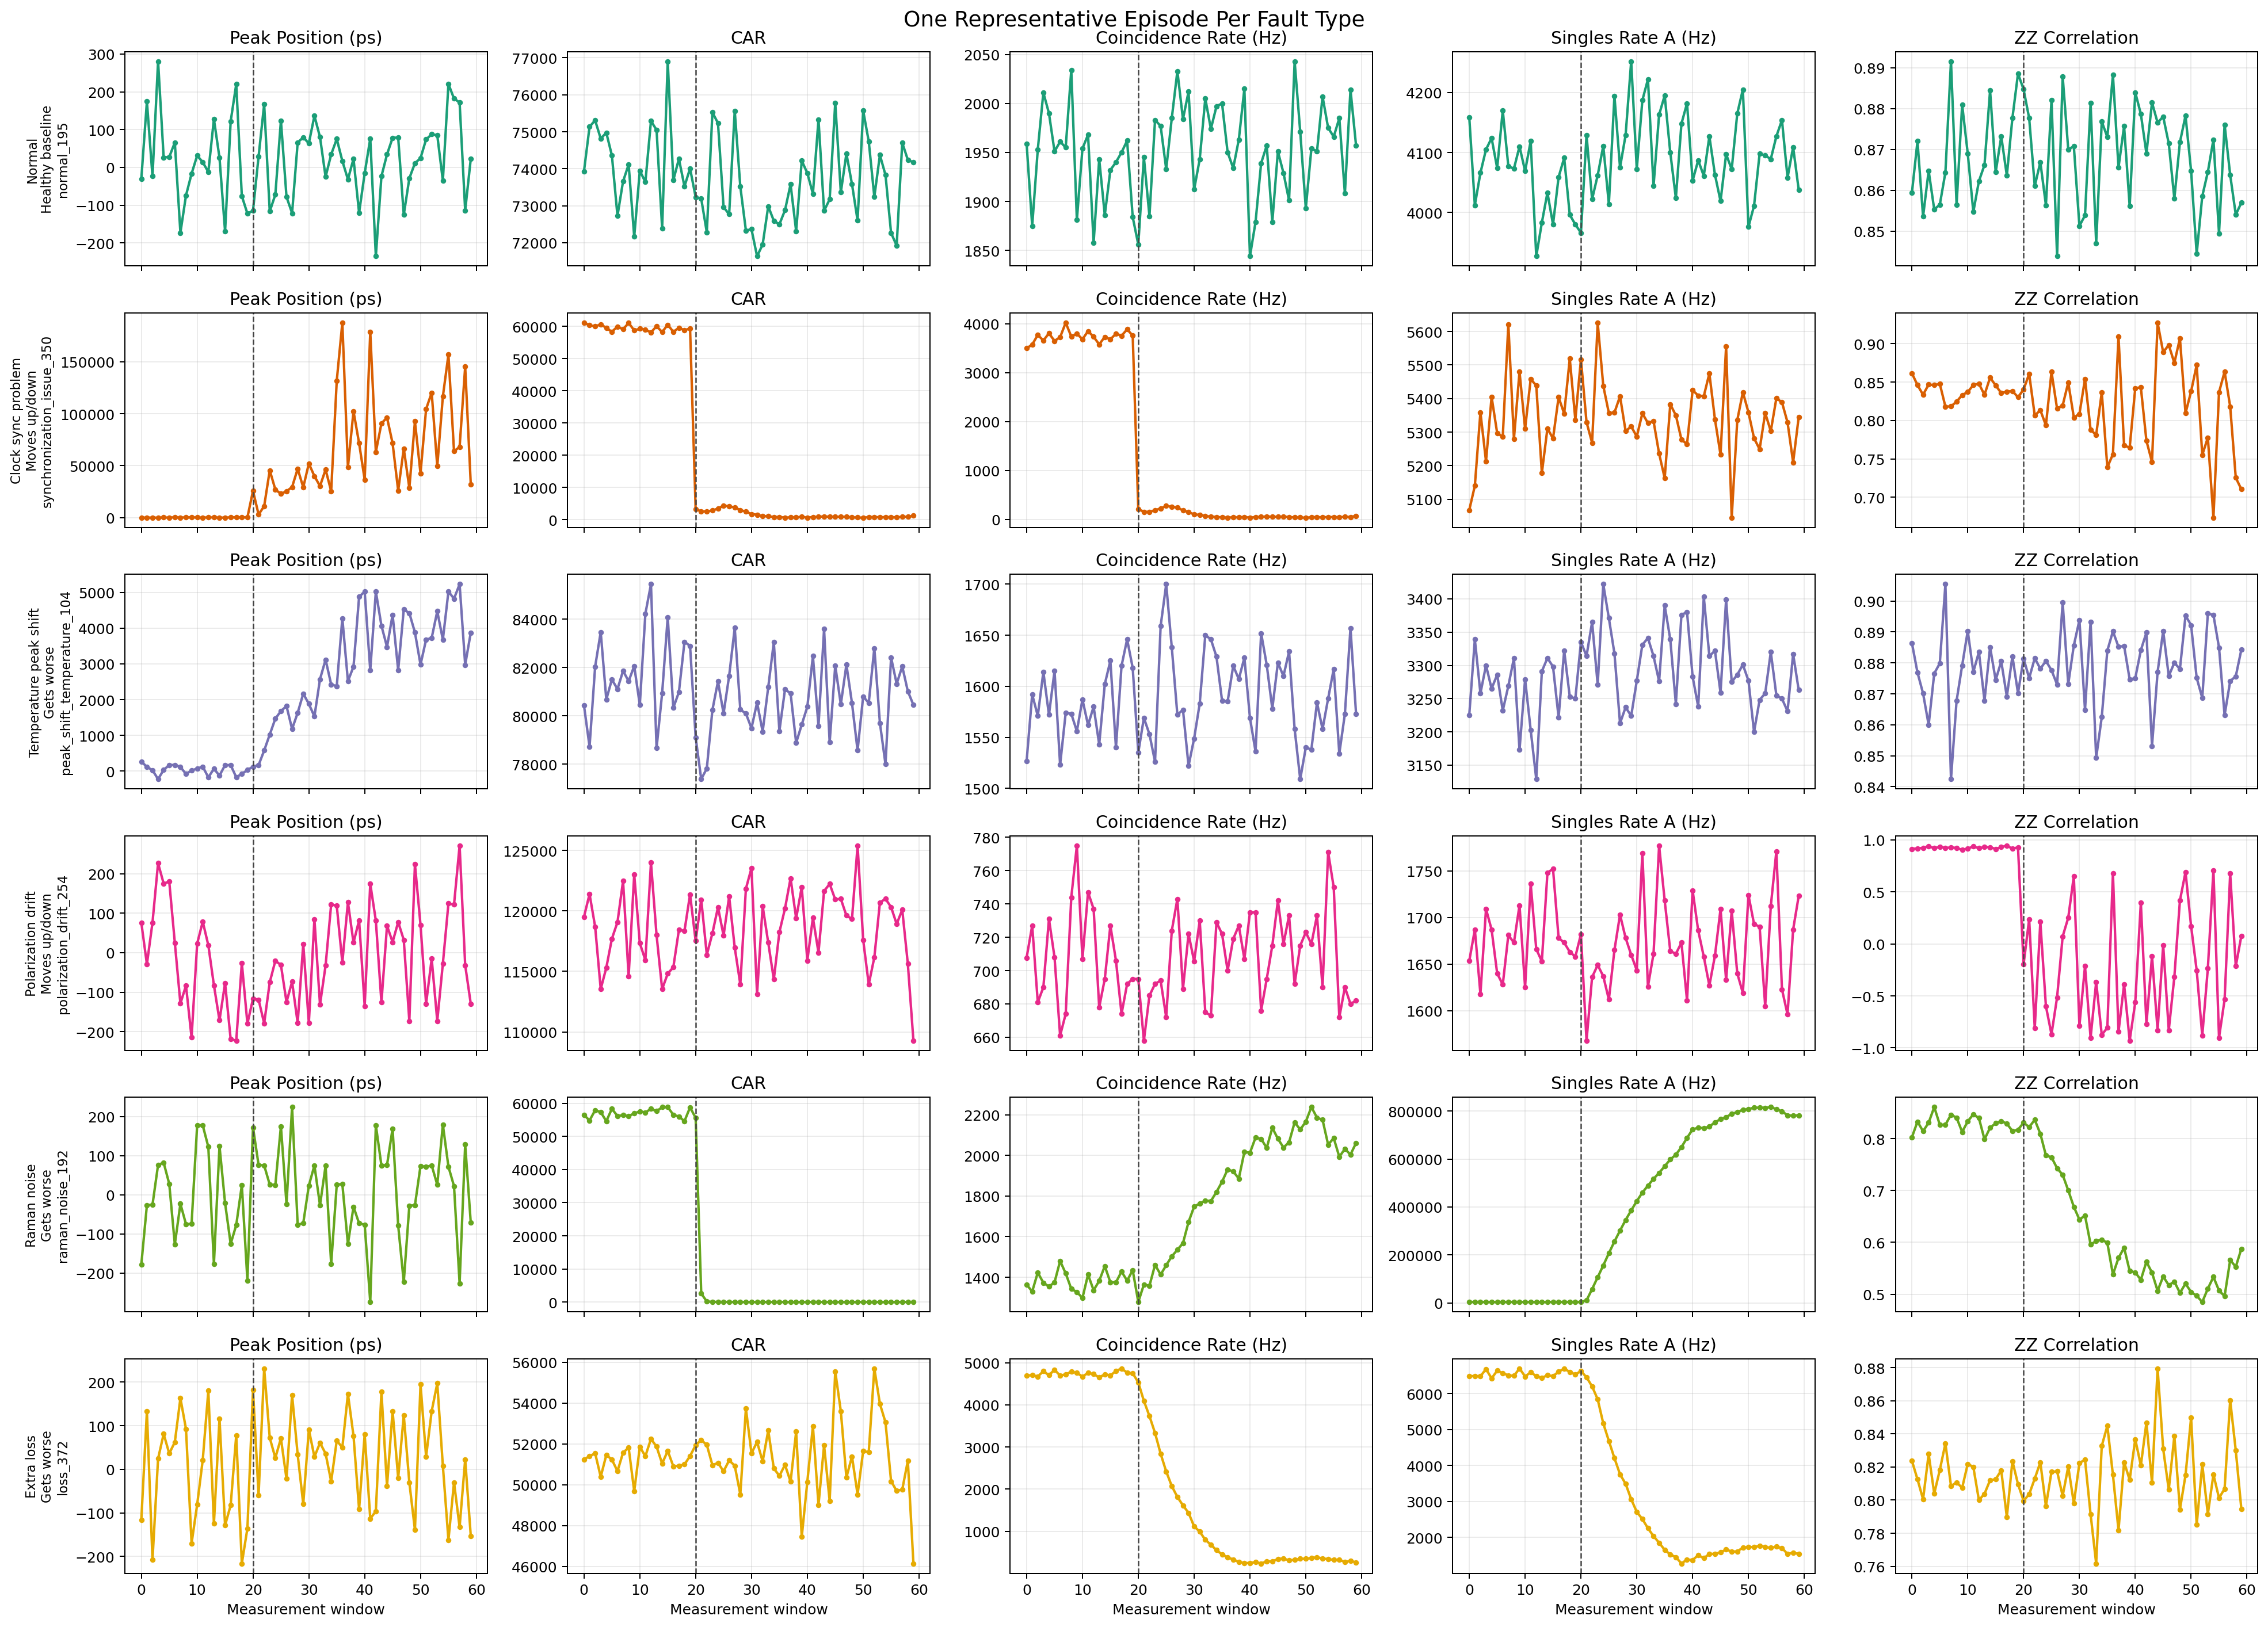

In [6]:
plot_representative_fault_examples(observable, validation, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / '03_representative_fault_examples.png')))


## Plot 4: Different Ways The Same Fault Can Evolve

The final training data should not teach the model that a fault always follows one simple ramp. This plot shows the main diagnostic signal for each fault across the four trajectory styles.

Each subplot is one real episode, not an average. The metric shown depends on the fault: for example, polarization drift uses ZZ correlation, Raman noise uses CAR, and loss uses coincidence rate.


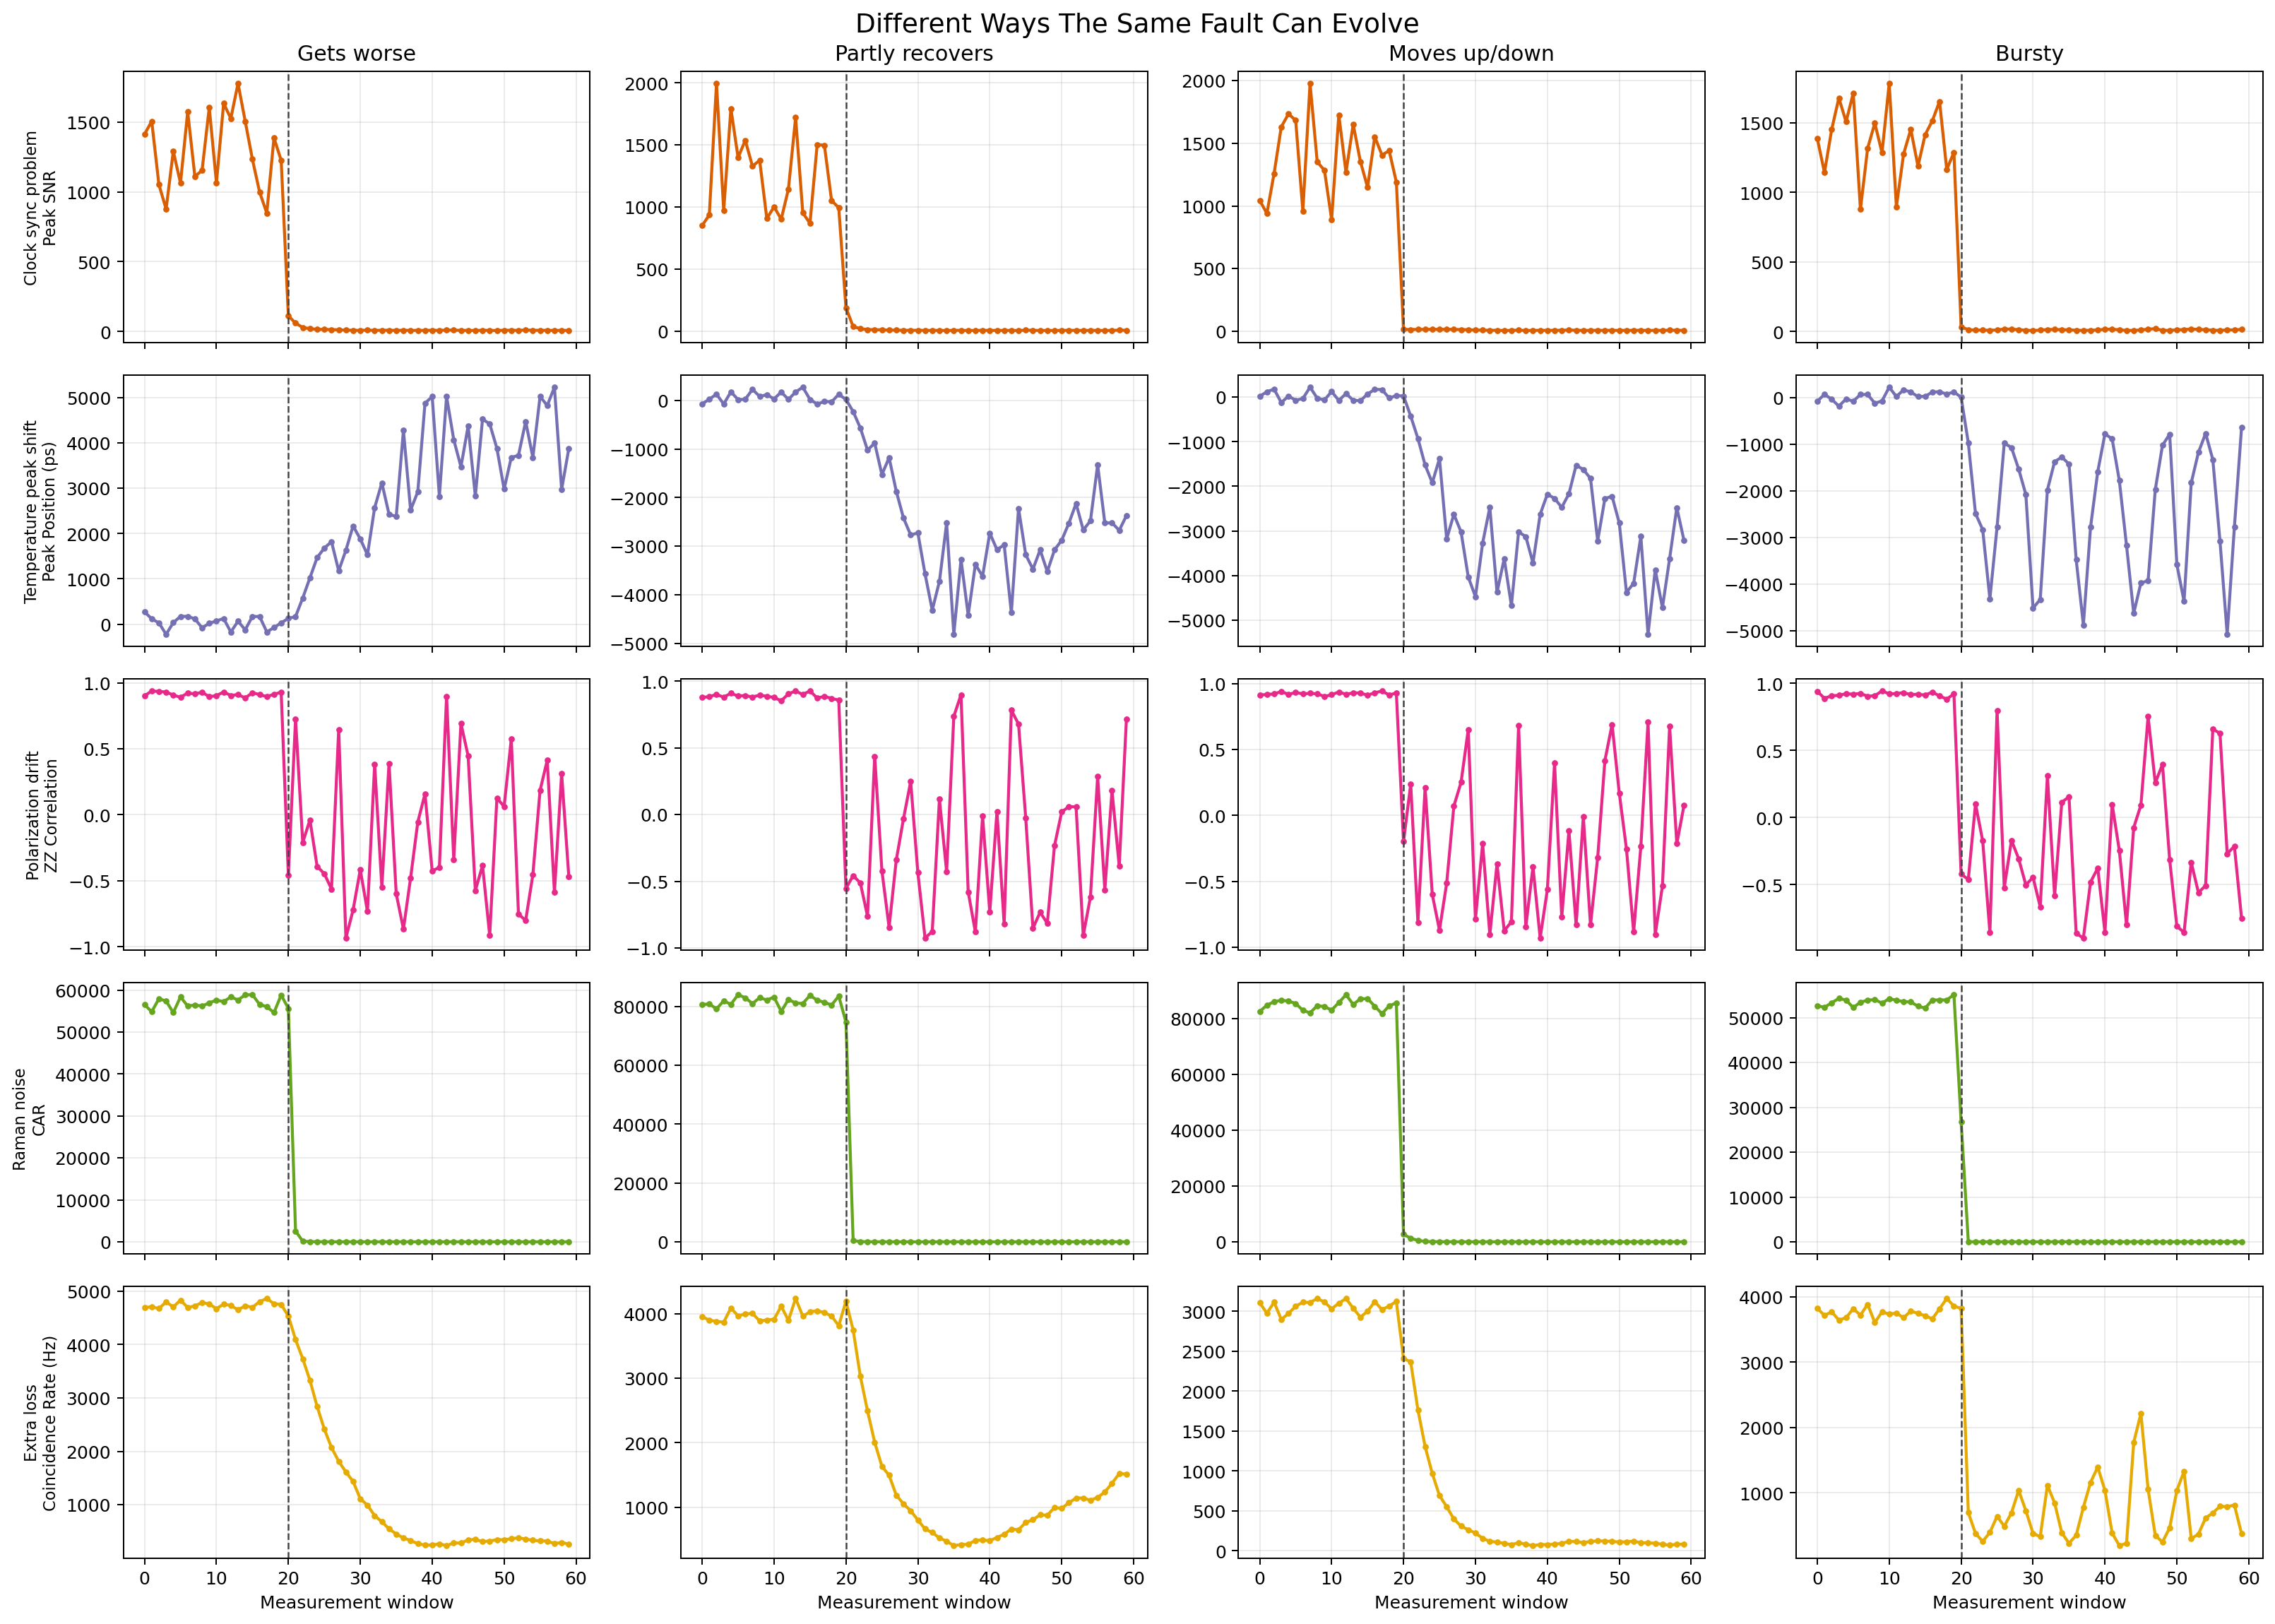

In [7]:
plot_fault_trajectory_styles(observable, validation, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / '04_fault_trajectory_styles.png')))


## Plot 5: Temperature Fault On Physical Time

Temperature changes should not look like they happen over one simulated minute. This plot uses `physical_time_h`, so the temperature fault can span 24 hours while each point still comes from a short measurement window.

Use this plot to check whether the temperature telemetry and peak position move together in a realistic way.


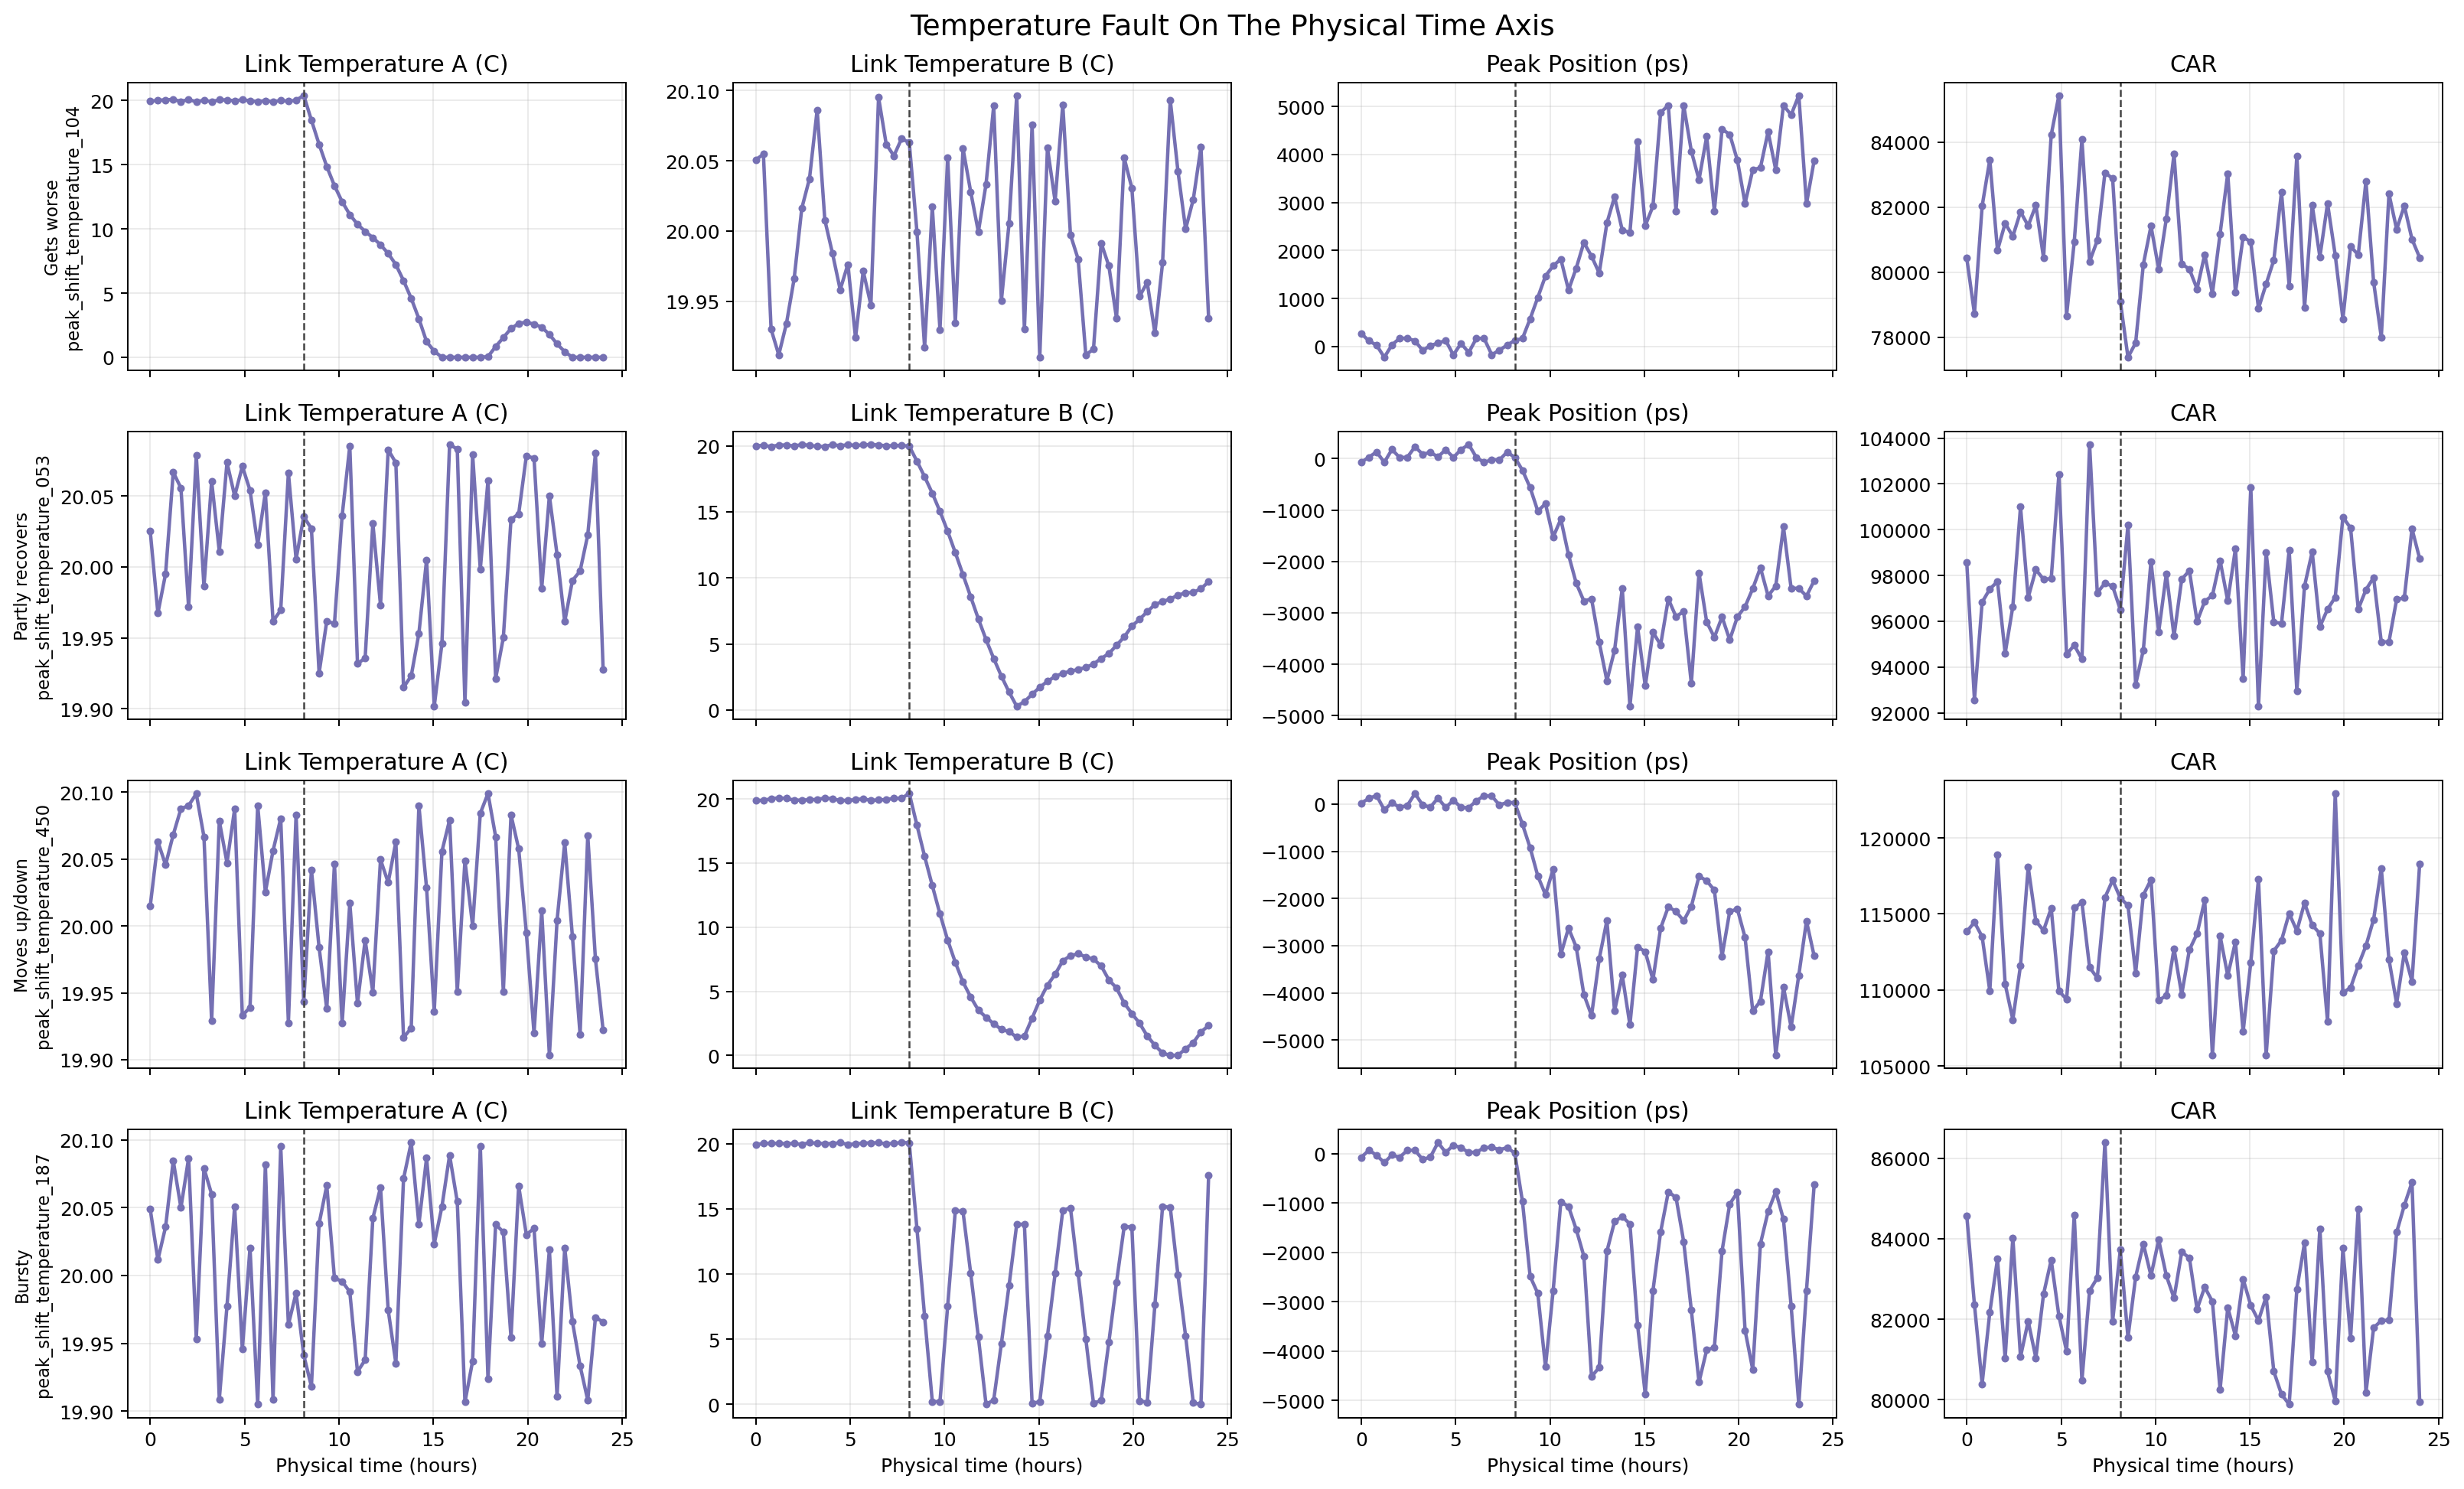

In [8]:
plot_temperature_physical_time(observable, validation, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / '05_temperature_physical_time.png')))


## Text Summary

This writes a compact Markdown summary next to the figures. Use it as a quick checklist after the plots are generated.


In [9]:
write_summary(observable, validation, metadata, OUTPUT_DIR)
summary_path = OUTPUT_DIR / 'dataset_review_summary.md'
print(summary_path.read_text(encoding='utf-8'))


# Dataset Review Summary

- Total sequences: `3000`
- Total windows: `180000`
- Episode duration: `60.0 s`
- Window duration: `1.0 s`
- Temperature physical span: `86400.0 s`
- Visibility stride: every `30` windows

## Plot Set

- `01_dataset_composition.png`: number of generated episodes by fault type and trajectory style.
- `02_fault_change_summary.png`: median before/after change after the fault starts.
- `03_representative_fault_examples.png`: one clear example episode per fault type.
- `04_fault_trajectory_styles.png`: the main signal for each fault across different trajectory styles.
- `05_temperature_physical_time.png`: temperature fault examples plotted against physical monitoring time.

## Label-Level Checks

### `normal`
- Avg delta peak position: `1.08 ps`
- Avg delta coincidence rate: `-0.04 Hz`
- Avg delta singles A: `0.74 Hz`
- Avg delta singles B: `-0.04 Hz`
- Avg delta ZZ correlation: `0.0002`

### `synchronization_issue`
- Avg delta peak position: `-11636.76 ps`
- Avg 

## What This Notebook Does Not Plot

It intentionally does not plot every raw column. The following are useful for model training, but usually not useful for visual review every time:

- every basis-specific coincidence rate (`hh`, `hv`, `vh`, `vv`, `pp`, `pm`, `mp`, `mm`)
- every rolling feature
- every raw histogram bin
- full JSON scenario metadata

If one of the five plots above looks wrong, then inspect the raw columns for that specific episode.
